In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.holtwinters import ExponentialSmoothing

### Загружаем данные

In [2]:
df = pd.read_csv("./data/data.csv", sep=";", decimal=",")

In [3]:
df_without_gaps = df[df["x4"] != " "].copy()

# Месяцы
months = df_without_gaps["date1"]

# Год
years = df_without_gaps["date2"]

time_series = df_without_gaps['x4'].astype(str).str.replace(',', '.').astype(float)

Посмотрим на график средней цены номера.

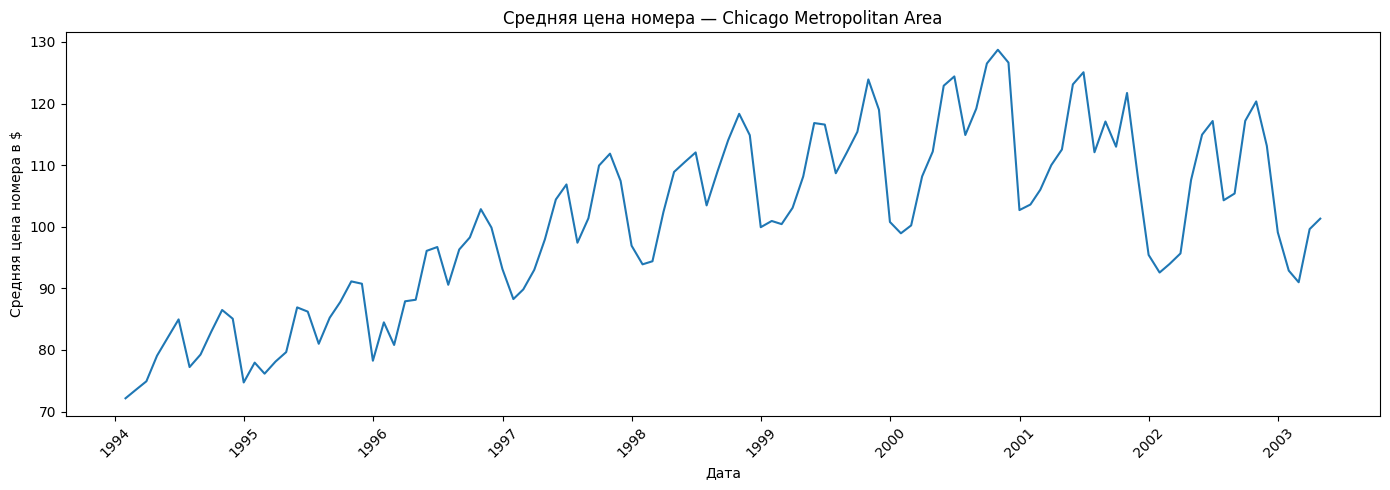

In [4]:
df_without_gaps['date'] = pd.date_range(start='1994-01', periods=len(df_without_gaps), freq='ME')

plt.figure(figsize=(14, 5))
sns.lineplot(x=df_without_gaps['date'] , y=time_series)

plt.title('Средняя цена номера — Chicago Metropolitan Area')
plt.xlabel('Дата')
plt.ylabel('Средняя цена номера в $')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- На графике виден определенный линейный тренд до 2001 года - после 2001 также линейный, но уже отрицательный.

- Мультипликативная сезонность.




### Используем метод экспоненциального сглаживания

In [5]:
exp_smooth = ExponentialSmoothing(
    time_series, 
    trend="additive",
    damped_trend=True,
    seasonal="multiplicative",
    seasonal_periods=12,
    initialization_method=None,   
).fit()

In [6]:
# len(time_series)

In [7]:
# time_series

In [8]:
predicted_series = exp_smooth.predict(start=0, end=len(time_series) + 7)

### Посмотрим на подгонку и прогноз

In [9]:
predicted_series

0       72.406569
1       73.834673
2       75.321954
3       79.509186
4       82.539500
          ...    
115    102.807251
116    107.301343
117    111.673970
118    108.127011
119     95.270768
Length: 120, dtype: float64

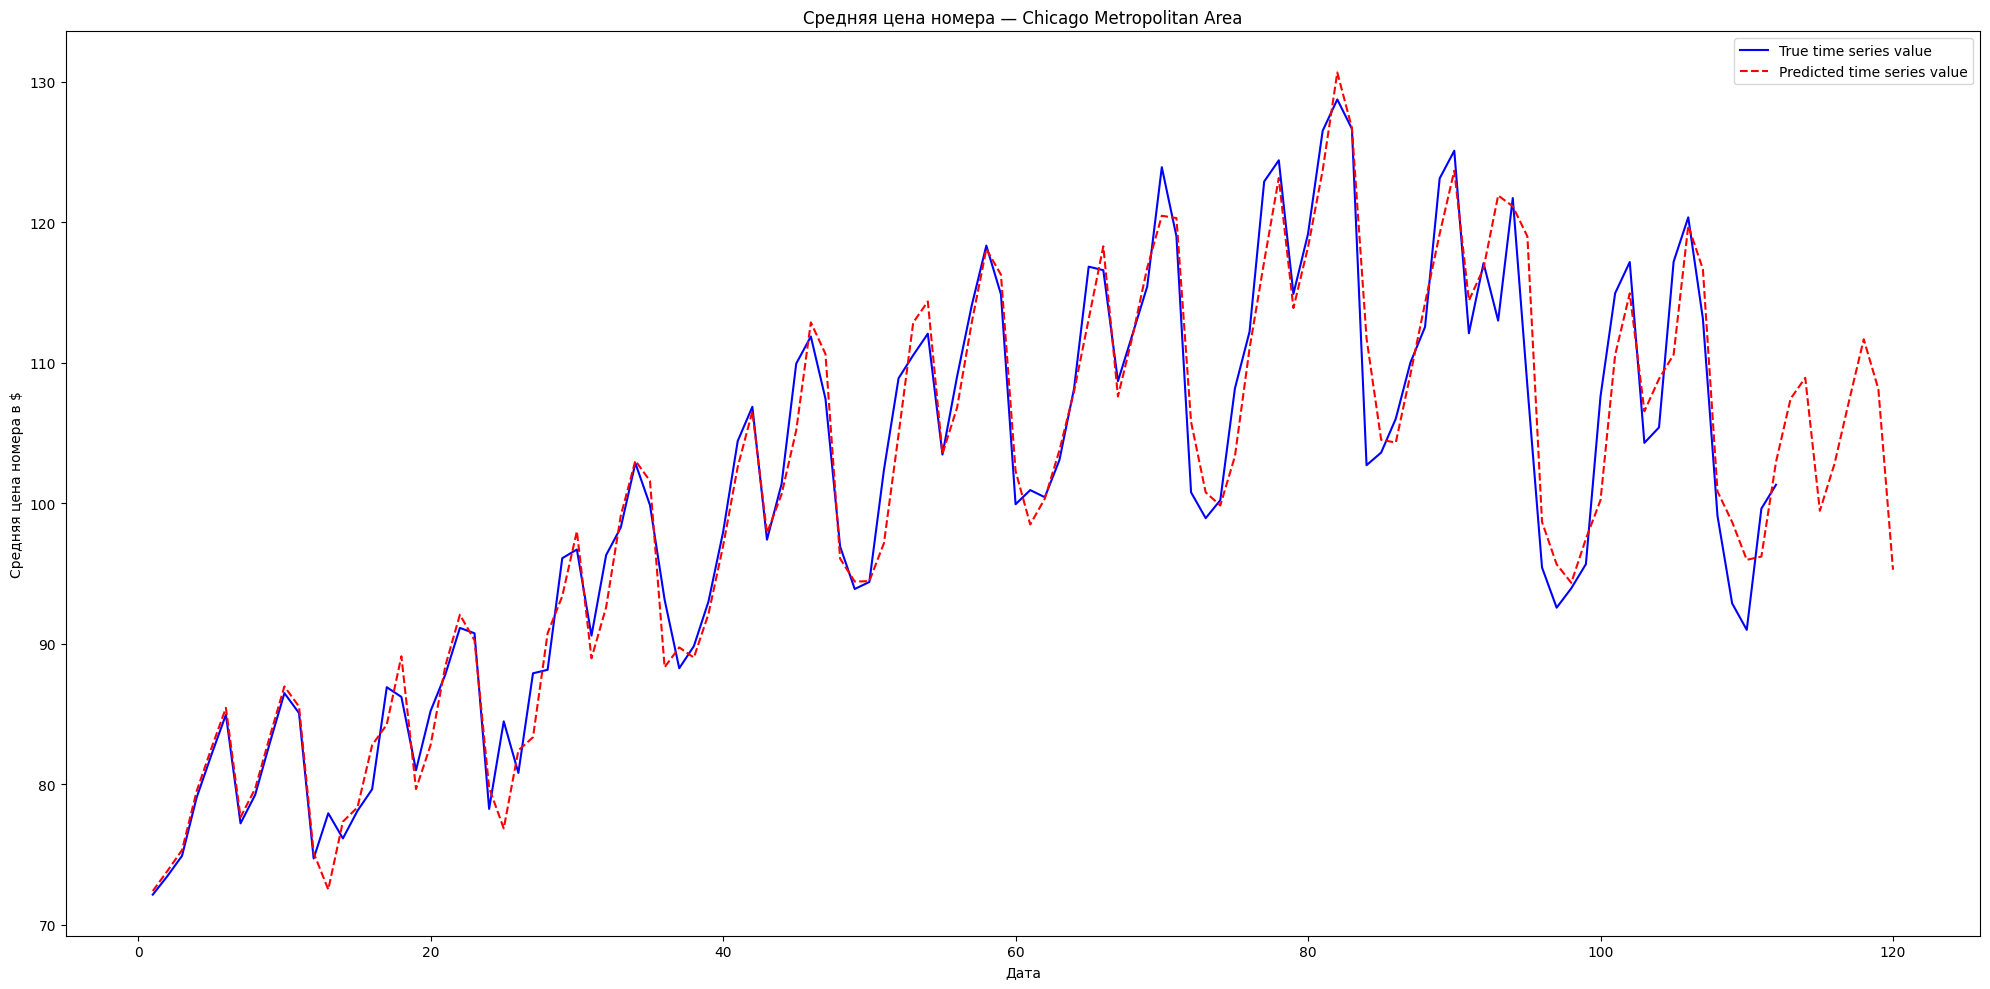

In [10]:
fig, ax = plt.subplots(figsize=(20, 10))

ax.plot(np.arange(1, len(time_series) + 1), time_series, label="True time series value", color="blue")
ax.plot(np.arange(1, len(predicted_series) + 1), predicted_series, "--", label="Predicted time series value", color="red")

plt.legend()
plt.title('Средняя цена номера — Chicago Metropolitan Area')
plt.xlabel('Дата')
plt.ylabel('Средняя цена номера в $')
plt.tight_layout()
plt.show()

In [11]:
print(f"Прогноз на следующие 8 месяцев: {predicted_series[-8:]}")

Прогноз на следующие 8 месяцев: 112    107.443559
113    108.930275
114     99.467484
115    102.807251
116    107.301343
117    111.673970
118    108.127011
119     95.270768
dtype: float64


In [12]:
# time_series

In [13]:
# dir(exp_smooth)
exp_smooth.params

{'smoothing_level': np.float64(0.5940907596369969),
 'smoothing_trend': np.float64(0.0),
 'smoothing_seasonal': np.float64(0.08773560240999417),
 'damping_trend': np.float64(0.9898980277114205),
 'initial_level': np.float64(90.567),
 'initial_trend': np.float64(0.3253472222222224),
 'initial_seasons': array([0.79664779, 0.81122263, 0.82712246, 0.87294489, 0.90617996,
        0.93809003, 0.85262844, 0.87504279, 0.91567569, 0.9549836 ,
        0.9393046 , 0.82502457]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

- smoothing_trend = 0.0 - тренд остается равным изначальному значению с поправкой на затухание

- smoothing_seasonal = 0.087735 - оценка сезонности меняется слабо

- smoothing_level = 0.59409 - модель довольно сильно реагирует на свежие данные